# Train or resume ResNet-18 and EfficientNet-B0
This is the notebook entry point to the same tested training code used by the application. It supports a fresh training run when the prepared data are available and resumes interrupted runs from optimizer, scheduler, scaler and random states.

**The delivered run is already trained.** Running the cell below recognizes the completed run and preserves its results. For a new experiment, first archive the existing models/results and edit `config.yaml`; never merge official validation into training.

Both baselines use frozen ImageNet image encoders, mean/max study-level slice aggregation and trained multilabel heads. Encoding is FP32 because the T500 produced nonfinite FP16 convolution outputs; head optimization uses mixed precision.


In [1]:
from pathlib import Path
import sys, json
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / "config.yaml").exists() and (p / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from KneeAssist-AI or its notebooks folder.")
sys.path.insert(0, str(ROOT))
from src.utils import config
cfg = config(ROOT / "config.yaml")
print("Project:", ROOT)
print("Python:", sys.executable)


Project: C:\Users\HP\Desktop\KneeAssist-AI
Python: C:\Users\HP\Desktop\KneeAssist-AI\.venv\Scripts\python.exe


In [2]:
import pandas as pd
from IPython.display import display, Image
for section in ["model", "preprocessing", "training"]:
    print(section.upper())
    display(cfg[section])


MODEL


{'architectures': ['resnet18', 'efficientnet_b0'],
 'selected_architecture': 'auto',
 'encoder_pretrained': True,
 'encoder_precision': 'float32',
 'training_mode': 'staged_final_blocks',
 'pooling': 'mean_max',
 'hidden_dim': 128,
 'dropout': 0.5,
 'encoder_chunk_size': 4}

PREPROCESSING


{'image_size': 224,
 'slices_per_plane': 12,
 'percentile_low': 1.0,
 'percentile_high': 99.0,
 'max_slices': 512,
 'max_dimension': 1024,
 'max_upload_mb': 100,
 'planes': ['axial', 'coronal', 'sagittal']}

TRAINING


{'device': 'auto',
 'mixed_precision': True,
 'batch_size': 1,
 'epochs': 6,
 'learning_rate': 3e-05,
 'weight_decay': 0.01,
 'early_stopping_patience': 3,
 'scheduler_patience': 4,
 'scheduler_factor': 0.5,
 'num_workers': 0,
 'cpu_threads': 4,
 'modality_dropout': 0.1,
 'validation_fraction': 0.2,
 'gradient_clip': 5.0,
 'warmup_epochs': 40,
 'gradient_accumulation': 4,
 'encoder_learning_rate': 1e-05}

In [3]:
# Viewing a notebook never starts a second training process.
print("Frozen baseline resume: .venv/Scripts/python.exe -m src.training.train --config configs/mrnet_fresh_01.yaml --resume")
print("Improvement pipeline: .venv/Scripts/python.exe -m scripts.complete_improvement")
print("Check notebook 08 for the active improvement process before launching anything.")

Frozen baseline resume: .venv/Scripts/python.exe -m src.training.train --config configs/mrnet_fresh_01.yaml --resume
Improvement pipeline: .venv/Scripts/python.exe -m scripts.complete_improvement
Check notebook 08 for the active improvement process before launching anything.


,Architecture,Selected stage,Best epoch,Epochs run,Internal validation AUROC
0,resnet18,final_encoder_blocks_finetuned,5,6,0.848459
1,efficientnet_b0,frozen_warmup,0,3,0.853162
2,efficientnet_b0,incumbent_frozen_baseline,3,13,0.847778


Selected using validation AUROC: efficientnet_b0
resnet18


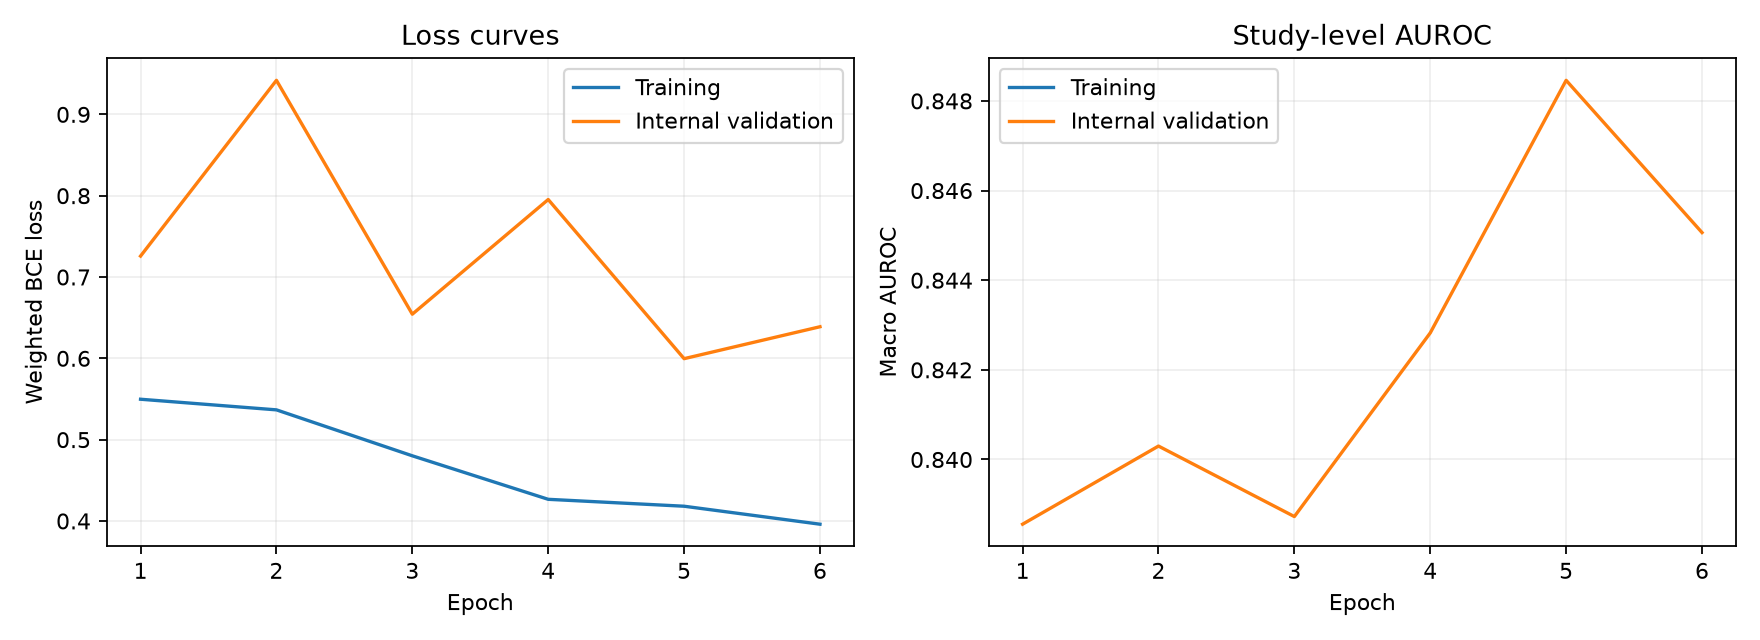

efficientnet_b0


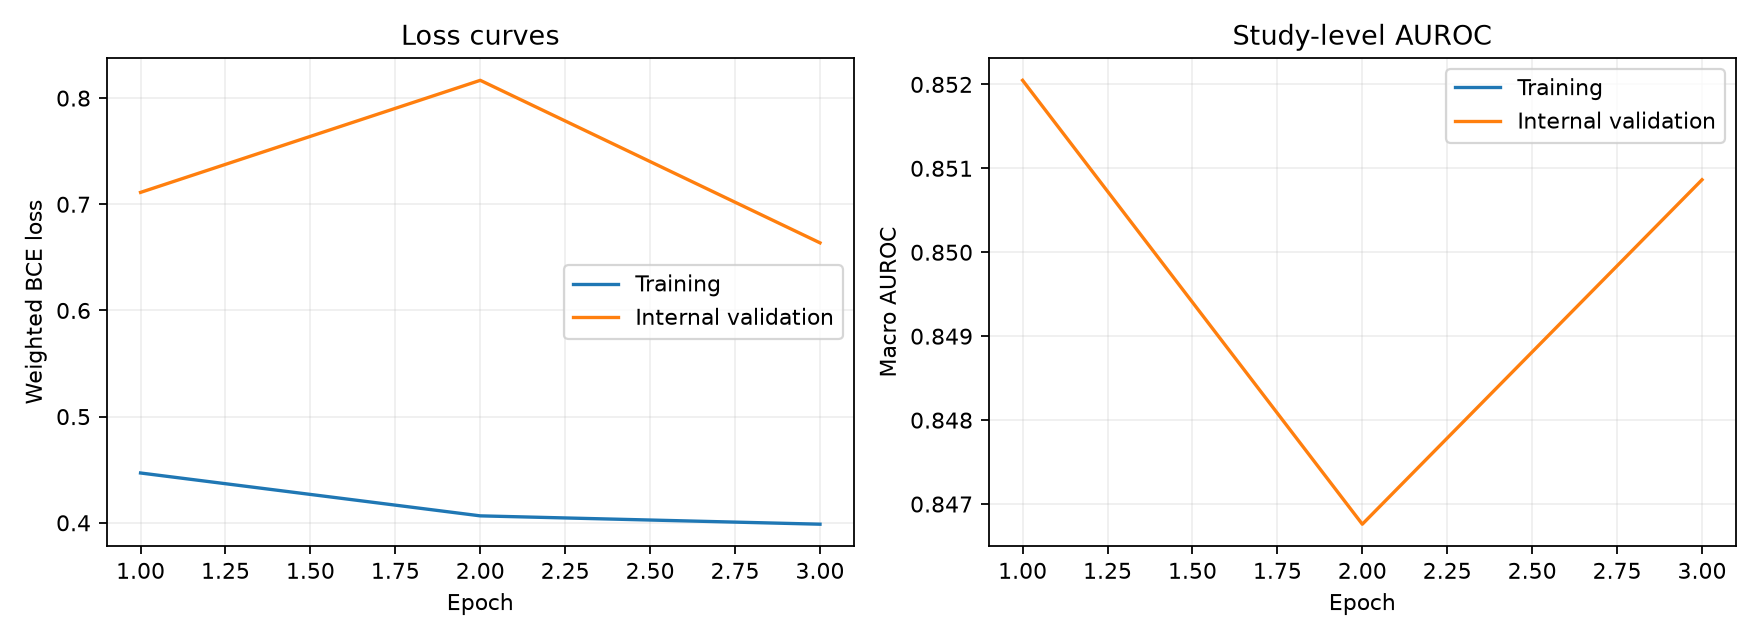

In [4]:
comparison = json.loads((ROOT / cfg["evaluation"]["directory"] / "model_comparison.json").read_text())
display(pd.DataFrame([{"Architecture": m["architecture"], "Selected stage": m.get("stage",m.get("candidate","historical baseline")), "Best epoch": m["selected_epoch"], "Epochs run": m["epochs_run"], "Internal validation AUROC": m["metrics"]["macro"]["auroc"]} for m in comparison["models"]]))
print("Selected using validation AUROC:", comparison["winner"])
for architecture in cfg["model"]["architectures"]:
    print(architecture)
    display(Image(filename=str(ROOT / cfg["evaluation"]["directory"] / architecture / "training_validation_curves.png")))


In [5]:
print("Active checkpoint:", ROOT / cfg["evaluation"]["checkpoint"])
print("Existence:", (ROOT / cfg["evaluation"]["checkpoint"]).is_file())
print("Historical resume diagnostics are under results/diagnostics; they do not verify the current fine-tuning run.")

Active checkpoint: C:\Users\HP\Desktop\KneeAssist-AI\runs\mri_finetune_02\models\best_model.pth
Existence: True
Historical resume diagnostics are under results/diagnostics; they do not verify the current fine-tuning run.


## Why validation controls selection
Training AUROC can become very high while validation AUROC stops improving. Early stopping and best-checkpoint selection retain the checkpoint with stronger validation ranking. Training accuracy is not the model-selection criterion. Avoid using final validation results to repeatedly tune the same experiment.
